# Paper I Methodology on Synthetic DS1

This notebook presents the Paper I modelling methodology based on **DS1**, a public synthetic replacement for the proprietary D1 dataset.

Paper I:
*Øien, Christian Dalheim; Ringen, Geir. Data-driven through-process modelling
of aluminum extrusion: Predicting mechanical properties. Manufacturing
Letters 41 (2024), 1274–1281.
DOI: https://doi.org/10.1016/j.mfglet.2024.09.154*


The notebook applies the comparative modelling structure of the paper in a public and transparent form using repository data products only. It evaluates:

- a NaMo-based physics estimate,
- a data-driven XGBoost model,
- a simple hybrid model using NaMo estimates as additional inputs, and
- a baseline alloy-average predictor.

The notebook assumes that the synthetic input files have already been generated by `generate_DS1.ipynb` at `data/DS1.xlsx`.





## 1. Repository assumptions and required inputs

It expects the following input files in `data/`:

- `DS1.xlsx`: synthetic DS1 data with chemistry, measured properties, and ML-ready one-hot encoded categorical columns
- `NaMo_syntetic.xlsx`: synthetic NaMo estimates with the same row index as `DS1.xlsx`

These two files are loaded separately and joined by index in this notebook.

In [1]:
from pathlib import Path
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score

import plot_utils

warnings.filterwarnings("ignore", category=FutureWarning)
mpl.rcParams["figure.dpi"] = 150 # paper uses 300

REPO_DIR = Path.cwd().resolve()
DS1_FILE = REPO_DIR / "data" / "DS1.xlsx"
NAMO_FILE = REPO_DIR / "data" / "NaMo_syntetic.xlsx"

PLOT_FOLD_XGB = 4
PLOT_FOLD_HYBRID = 2
PLOT_FOLD_NAMO = 4

## 2. Data products and column conventions

`DS1.xlsx` contains the synthetic measured dataset used for modelling. It includes:

- alloy labels as strings,
- oven-recipe labels as strings,
- chemistry variables,
- measured targets (`Rp02`, `Rm`), and
- one-hot encoded categorical columns used directly for machine learning.

`NaMo_syntetic.xlsx` contains the corresponding synthetic NaMo estimates:

- `NaMo Rp02`
- `NaMo Rm`

In [2]:
IMS_OPTIONS = ["6060", "6063", "6005 v1", "6005 v2", "6082 v1", "6082 v2", "6082 v3"]
RECIPE_OPTIONS = [
    "Oven Recipe 1",
    "Oven Recipe 2",
    "Oven Recipe 3",
    "Oven Recipe 4",
    "Oven Recipe 5",
    "Oven Recipe 6",
]

CHEMISTRY_COLS = ["Al", "B", "Ca", "Cr", "Cu", "Fe", "Mg", "Mn", "Ni", "Si", "Ti", "V", "Zn", "Zr"]
CATEGORICAL_COLS = ["IMS", "Oven Recipe"]
ONEHOT_COLS = [f"IMS_{v}" for v in IMS_OPTIONS] + [f"Oven Recipe_{v}" for v in RECIPE_OPTIONS]
TARGET_COLS = ["Rp02", "Rm"]
NAMO_COLS = ["NaMo Rp02", "NaMo Rm"]

DS1_REQUIRED_COLS = CATEGORICAL_COLS + CHEMISTRY_COLS + ONEHOT_COLS + TARGET_COLS
NAMO_REQUIRED_COLS = NAMO_COLS

MODEL_PARAMS = {
    "objective": "reg:squarederror",
    "random_state": 42,
    "subsample": 0.8,
    "colsample_bytree": 0.5,
    "alpha": 0.1,
    "lambda": 0.9,
    "gamma": 0.01,
    "learning_rate": 0.08,
    "max_depth": 4,
    "n_estimators": 500,
}

## 3. Load data

Loading `data/DS1.xlsx` and `data/NaMo_syntetic.xlsx`. If it is missing, run `generate_DS1.ipynb` first.

In [3]:
def load_inputs(ds1_path, namo_path):
    if not ds1_path.exists():
        raise FileNotFoundError(f"Expected DS1 workbook at {ds1_path}. Run generate_DS1.ipynb first.")
    if not namo_path.exists():
        raise FileNotFoundError(f"Expected NaMo workbook at {namo_path}. Run generate_DS1.ipynb first.")

    ds1 = pd.read_excel(ds1_path, index_col=0)
    namo = pd.read_excel(namo_path, index_col=0)

    missing_ds1 = [col for col in DS1_REQUIRED_COLS if col not in ds1.columns]
    missing_namo = [col for col in NAMO_REQUIRED_COLS if col not in namo.columns]

    if missing_ds1:
        raise ValueError(f"DS1 is missing required columns: {missing_ds1}")
    if missing_namo:
        raise ValueError(f"NaMo workbook is missing required columns: {missing_namo}")

    ds1 = ds1.loc[:, DS1_REQUIRED_COLS].copy()
    namo = namo.loc[:, NAMO_REQUIRED_COLS].copy()

    ds1["IMS"] = ds1["IMS"].astype(str)
    ds1["Oven Recipe"] = ds1["Oven Recipe"].astype(str)
    ds1["alloy"] = ds1["IMS"]

    namo = namo.reindex(ds1.index)
    if namo.isna().any().any():
        raise ValueError("NaMo workbook could not be aligned cleanly to DS1 by index.")

    frame = ds1.join(namo, how="left")
    return frame

ds1 = load_inputs(DS1_FILE, NAMO_FILE)
print(f"Loaded DS1 rows: {len(ds1):,}")
print(f"Loaded DS1 columns: {list(ds1.columns)}")
display(ds1.head())

Loaded DS1 rows: 9,000
Loaded DS1 columns: ['IMS', 'Oven Recipe', 'Al', 'B', 'Ca', 'Cr', 'Cu', 'Fe', 'Mg', 'Mn', 'Ni', 'Si', 'Ti', 'V', 'Zn', 'Zr', 'IMS_6060', 'IMS_6063', 'IMS_6005 v1', 'IMS_6005 v2', 'IMS_6082 v1', 'IMS_6082 v2', 'IMS_6082 v3', 'Oven Recipe_Oven Recipe 1', 'Oven Recipe_Oven Recipe 2', 'Oven Recipe_Oven Recipe 3', 'Oven Recipe_Oven Recipe 4', 'Oven Recipe_Oven Recipe 5', 'Oven Recipe_Oven Recipe 6', 'Rp02', 'Rm', 'alloy', 'NaMo Rp02', 'NaMo Rm']


,IMS,Oven Recipe,Al,B,Ca,Cr,Cu,Fe,Mg,Mn,...,Oven Recipe_Oven Recipe 2,Oven Recipe_Oven Recipe 3,Oven Recipe_Oven Recipe 4,Oven Recipe_Oven Recipe 5,Oven Recipe_Oven Recipe 6,Rp02,Rm,alloy,NaMo Rp02,NaMo Rm
100000,6082 v1,Oven Recipe 5,98.3634,0.00117,0.00178,0.00610,0.02964,0.10159,0.66644,0.03827,...,0,0,0,1,0,309.6,338.4,6082 v1,273.6,287.1
100001,6005 v2,Oven Recipe 4,98.4711,0.00141,0.00219,0.00584,0.02362,0.10750,0.56027,0.03456,...,0,0,1,0,0,307.5,334.6,6005 v2,280.8,301.6
100002,6005 v2,Oven Recipe 6,98.6840,0.00125,0.00127,0.00269,0.01597,0.09469,0.46049,0.01592,...,0,0,0,0,1,291.0,320.8,6005 v2,258.6,268.9
100003,6060,Oven Recipe 1,98.9386,0.00099,0.00207,0.00308,0.00000,0.11189,0.30000,0.00692,...,0,0,0,0,0,245.8,268.4,6060,243.8,269.9
100004,6005 v2,Oven Recipe 6,98.5566,0.00153,0.00218,0.00559,0.01998,0.11586,0.57184,0.01956,...,0,0,0,0,1,308.6,331.4,6005 v2,281.1,296.0


## 4. Model representations and cross-validation setup

Paper I compares several modelling representations built from the same underlying rows:

- **NaMo**: cached synthetic physics-based estimates
- **XGBoost**: chemistry + one-hot encoded alloy/recipe variables
- **Hybrid**: the XGBoost input space augmented with NaMo estimates
- **Baseline**: alloy-average predictor

The design matrices are constructed directly from the prepared DS1 columns.

Cross-validation is performed in an alloy-stratified manner.

In [4]:
def make_design_matrix(frame, include_namo):
    numeric_cols = CHEMISTRY_COLS + (NAMO_COLS if include_namo else [])
    numeric = frame.loc[:, numeric_cols].copy()
    numeric = (numeric - numeric.mean()) / numeric.std()
    categorical = frame.loc[:, ONEHOT_COLS].copy()
    return pd.concat([numeric, categorical], axis=1)

def make_alloy_stratified_folds_original(frame, group_col="IMS", n_folds=5):
    alloys = frame[group_col].unique()
    all_fold_ids = []

    for alloy in alloys:
        df_alloy = frame.loc[frame[group_col] == alloy]
        alloy_ids = df_alloy.index.values

        alloy_fold_ids = []
        for i in range(n_folds):
            start = int(np.floor(len(df_alloy) * i / n_folds))
            stop = int(np.floor(len(df_alloy) * (i + 1) / n_folds)) - 1
            alloy_fold_ids.append(alloy_ids[start:stop])
        all_fold_ids.append(alloy_fold_ids)

    single_fold_dfs = []
    for j in range(n_folds):
        single_fold_df = pd.DataFrame()
        for i in range(len(alloys)):
            tmp_df = frame.loc[all_fold_ids[i][j], :]
            single_fold_df = pd.concat([single_fold_df, tmp_df])
        single_fold_dfs.append(single_fold_df)

    return single_fold_dfs

X_xgb = make_design_matrix(ds1, include_namo=False)
X_hybrid = make_design_matrix(ds1, include_namo=True)

folds = make_alloy_stratified_folds_original(
    ds1.loc[:, ["IMS", "alloy"] + TARGET_COLS + NAMO_COLS].copy(),
    group_col="IMS",
    n_folds=5,
)

print(f"X_xgb shape: {X_xgb.shape}")
print(f"X_hybrid shape: {X_hybrid.shape}")
print("Fold sizes:", [len(fold) for fold in folds])

X_xgb shape: (9000, 27)
X_hybrid shape: (9000, 29)
Fold sizes: [1791, 1793, 1793, 1793, 1795]


## 5. Evaluation protocol and helper functions

This section defines the metrics and helper functions used throughout the notebook.

The XGBoost and hybrid models are evaluated using the Paper I hyperparameter configuration. Performance is summarized with:

- coefficient of determination, $R^2$
- root-mean-square error, RMSE

for both target variables:

- $R_{p0.2}$
- $R_m$

The helper functions below implement model fitting, prediction, cross-validation aggregation, and summary formatting.

In [5]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metric_row(y_true, y_pred):
    return {
        "Rp02 R2": r2_score(y_true["Rp02"], y_pred["Rp02"]),
        "Rp02 RMSE": rmse(y_true["Rp02"], y_pred["Rp02"]),
        "Rm R2": r2_score(y_true["Rm"], y_pred["Rm"]),
        "Rm RMSE": rmse(y_true["Rm"], y_pred["Rm"]),
    }

def fit_xgb(X_train, y_train):
    model = xgb.XGBRegressor(**MODEL_PARAMS)
    model.fit(X_train.to_numpy(), y_train.to_numpy())
    return model

def predict_xgb(model, X_test, index):
    pred = model.predict(X_test.to_numpy(dtype=np.float32))
    return pd.DataFrame(pred, index=index, columns=TARGET_COLS)

def evaluate_xgb_cv(X_full, folds):
    rows = []
    for fold_id, test_fold in enumerate(folds):
        train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)
        model = fit_xgb(X_full.loc[train_fold.index], train_fold.loc[:, TARGET_COLS])
        pred = predict_xgb(model, X_full.loc[test_fold.index], test_fold.index)
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def evaluate_namo_cv(folds):
    rows = []
    for test_fold in folds:
        pred = test_fold.loc[:, NAMO_COLS].rename(columns={"NaMo Rp02": "Rp02", "NaMo Rm": "Rm"})
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def evaluate_baseline_cv(folds):
    rows = []
    for fold_id, test_fold in enumerate(folds):
        train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)
        alloy_means = train_fold.groupby("IMS")[TARGET_COLS].mean()
        pred = test_fold.loc[:, ["IMS"]].join(alloy_means, on="IMS").loc[:, TARGET_COLS]
        rows.append(metric_row(test_fold.loc[:, TARGET_COLS], pred))
    return pd.DataFrame(rows, index=[f"fold_{i}" for i in range(len(folds))])

def summarize_metrics(metrics):
    return pd.Series({
        key: f"{metrics[key].mean():.2f} +/- {2 * metrics[key].std():.3f}"
        for key in ["Rp02 R2", "Rp02 RMSE", "Rm R2", "Rm RMSE"]
    })


## 6. Conduct analysis and compare models with the baseline

This section runs the full cross-validation methodology for all model representations and summarizes the results in a comparison table.


In [6]:
cv_results = {
    "NaMo": evaluate_namo_cv(folds),
    "XGBoost": evaluate_xgb_cv(X_xgb, folds),
    "Hybrid": evaluate_xgb_cv(X_hybrid, folds),
    "Baseline": evaluate_baseline_cv(folds),
}

summary_table = pd.DataFrame({name: summarize_metrics(metrics) for name, metrics in cv_results.items()}).T
summary_table.index.name = "Model"
display(summary_table)

display(pd.concat(cv_results, names=["Model", "Fold"]))


,Rp02 R2,Rp02 RMSE,Rm R2,Rm RMSE
Model,,,,
NaMo,0.55 +/- 0.016,28.52 +/- 0.559,0.44 +/- 0.023,34.28 +/- 0.710
XGBoost,0.96 +/- 0.003,8.32 +/- 0.262,0.96 +/- 0.002,9.28 +/- 0.236
Hybrid,0.96 +/- 0.002,8.34 +/- 0.241,0.96 +/- 0.002,9.29 +/- 0.216
Baseline,0.85 +/- 0.010,16.51 +/- 0.426,0.83 +/- 0.010,18.86 +/- 0.451


Rp02 R2  Rp02 RMSE     Rm R2    Rm RMSE
Model    Fold                                            
NaMo     fold_0  0.545855  28.810802  0.435936  34.624915
         fold_1  0.561884  28.077471  0.451888  33.935657
         fold_2  0.545430  28.588641  0.444659  33.975101
         fold_3  0.554874  28.457810  0.450771  34.179308
         fold_4  0.542359  28.673096  0.423820  34.683429
XGBoost  fold_0  0.963588   8.157890  0.960432   9.170608
         fold_1  0.959826   8.502304  0.958356   9.354035
         fold_2  0.962212   8.242678  0.957468   9.402405
         fold_3  0.961445   8.375278  0.959129   9.323774
         fold_4  0.961547   8.311411  0.960042   9.133629
Hybrid   fold_0  0.963446   8.173836  0.959850   9.237714
         fold_1  0.960262   8.456026  0.958332   9.356679
         fold_2  0.961375   8.333529  0.958137   9.328190
         fold_3  0.960664   8.459651  0.958355   9.411750
         fold_4  0.961778   8.286407  0.960014   9.136875
Baseline fold_0  0.855886  16.229719  0.837860  18.563915
         fold_1  0.843336  16.789879  0.824900  19.180711
         fold_2  0.846471  16.614549  0.828336  18.889482
         fold_3  0.852272  16.394249  0.834547  18.759636
         fold_4  0.847901  16.530113  0.828914  18.899492

## 7. Generate prediction plots

This section generates representative measured-versus-predicted scatter plots using one selected cross-validation fold for each model representation.


C:\Users\chrisdoi\AppData\Local\Temp\ipykernel_23372\422600577.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\chrisdoi\AppData\Local\Temp\ipykernel_23372\422600577.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


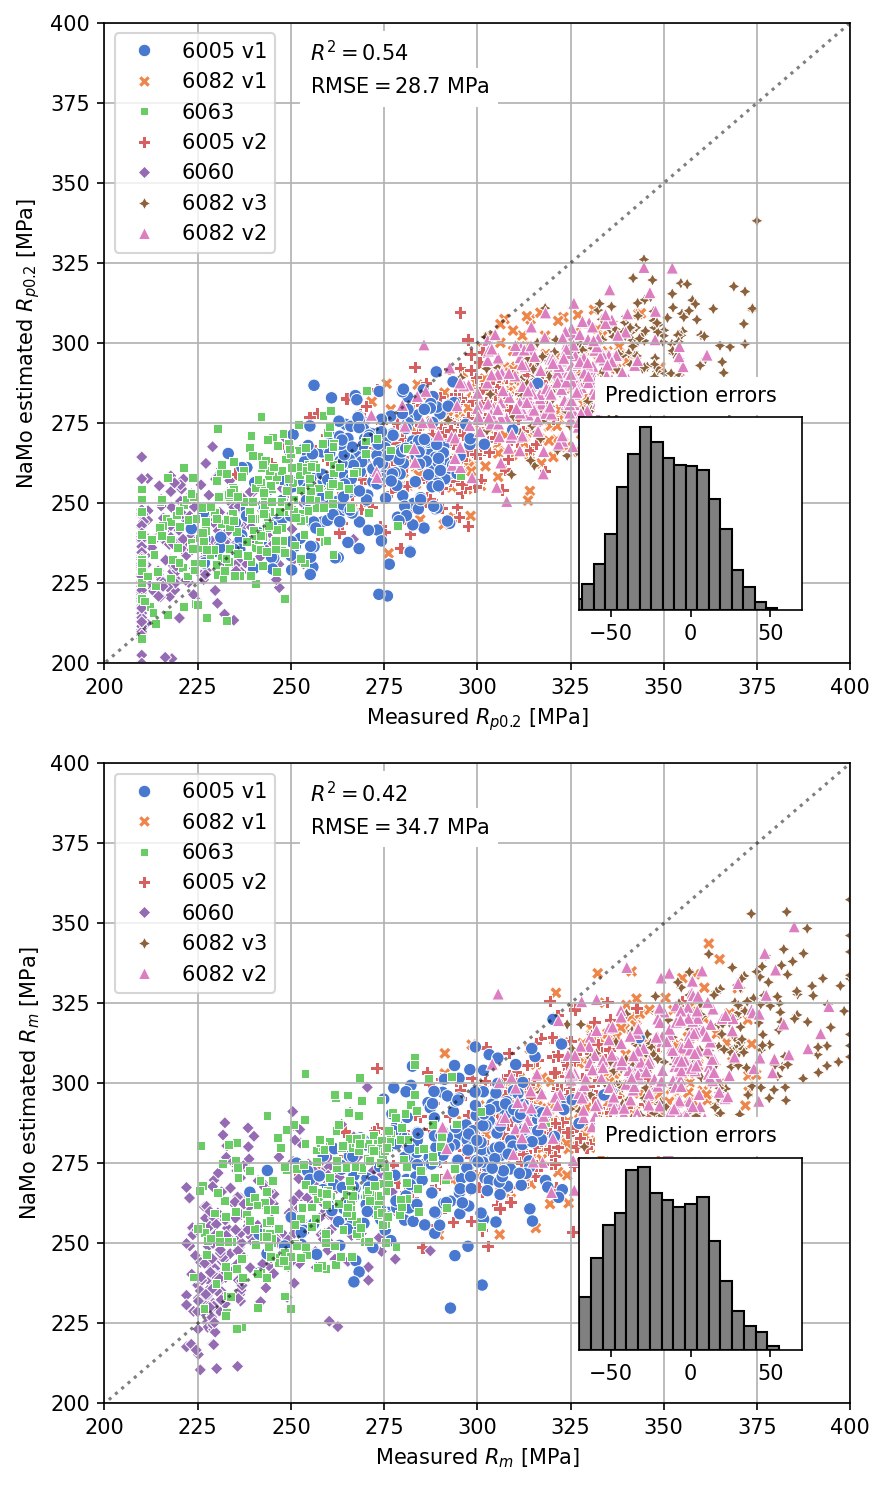

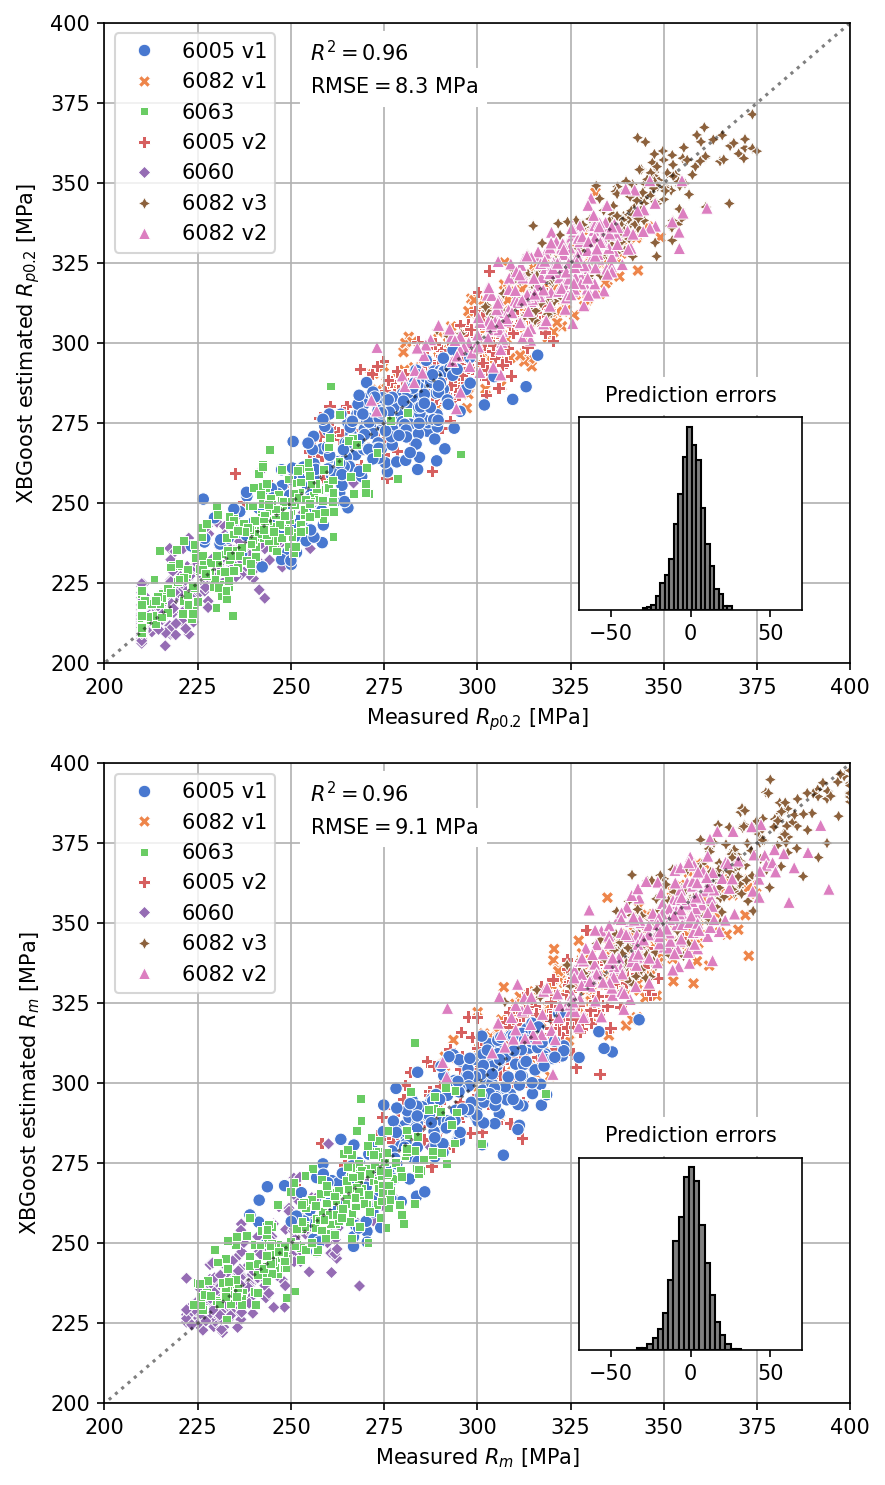

In [7]:
def predict_cv_fold(X_full, folds, fold_id):
    fold_id = min(fold_id, len(folds) - 1)
    test_fold = folds[fold_id].copy()
    train_fold = pd.concat([fold for i, fold in enumerate(folds) if i != fold_id], axis=0)

    model = fit_xgb(X_full.loc[train_fold.index], train_fold.loc[:, TARGET_COLS])
    pred = predict_xgb(model, X_full.loc[test_fold.index], test_fold.index)
    return test_fold, pred

# ---- NaMo plot  ----
namo_fold = folds[PLOT_FOLD_NAMO].copy()
namo_plot_df = namo_fold.loc[:, ["alloy", "Rp02", "Rm", "NaMo Rp02", "NaMo Rm"]]

fig_namo, [ax1, ax2] = plt.subplots(2, 1, figsize=(6, 10))
plot_utils.model_eval_plot(
    namo_plot_df,
    "Rp02",
    "NaMo Rp02",
    "alloy",
    "Measured $R_{p0.2}$ [MPa]",
    "NaMo estimated $R_{p0.2}$ [MPa]",
    ax1,
)
plot_utils.model_eval_plot(
    namo_plot_df,
    "Rm",
    "NaMo Rm",
    "alloy",
    "Measured $R_m$ [MPa]",
    "NaMo estimated $R_m$ [MPa]",
    ax2,
)
plt.tight_layout()

# ---- XGBoost plot ----
xgb_fold, xgb_pred = predict_cv_fold(X_xgb, folds, PLOT_FOLD_XGB)
xgb_plot_df = xgb_fold.loc[:, ["alloy", "Rp02", "Rm"]].join(xgb_pred.add_prefix("XGBoost "))

fig_xgb, [ax1, ax2] = plt.subplots(2, 1, figsize=(6, 10))
plot_utils.model_eval_plot(
    xgb_plot_df,
    "Rp02",
    "XGBoost Rp02",
    "alloy",
    "Measured $R_{p0.2}$ [MPa]",
    "XBGoost estimated $R_{p0.2}$ [MPa]",
    ax1,
)
plot_utils.model_eval_plot(
    xgb_plot_df,
    "Rm",
    "XGBoost Rm",
    "alloy",
    "Measured $R_m$ [MPa]",
    "XBGoost estimated $R_m$ [MPa]",
    ax2,
)
plt.tight_layout()

